# Bibliotecas

In [1]:
import os
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import torch
import random

from collections import Counter
from ultralytics import YOLO
from matplotlib.lines import Line2D

# Baixando Arquivos

In [22]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3


# Localizando Pastas

In [24]:
print(f"O path fornecido é: {path}")

def find_train_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'labels' in os.listdir(os.path.join(root, 'train')):
            return os.path.join(root, 'train')
    return None

real_train_path = find_train_folder(path)

if real_train_path:
    print(f"✅ Sucesso! A pasta de treino real é: {real_train_path}")
    # Atualizando o caminho base para o script
    base_data_path = os.path.dirname(real_train_path)
else:
    print("❌ Não encontramos a pasta 'train/labels'. Vamos listar o que tem no diretório:")
    print(os.listdir(path))

O path fornecido é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3
✅ Sucesso! A pasta de treino real é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data\train


# Auditoria dos Dados

🔍 Analisando... isso pode levar alguns segundos.


C:\Users\Maiquel\AppData\Local\Temp\ipykernel_17716\3678547624.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')


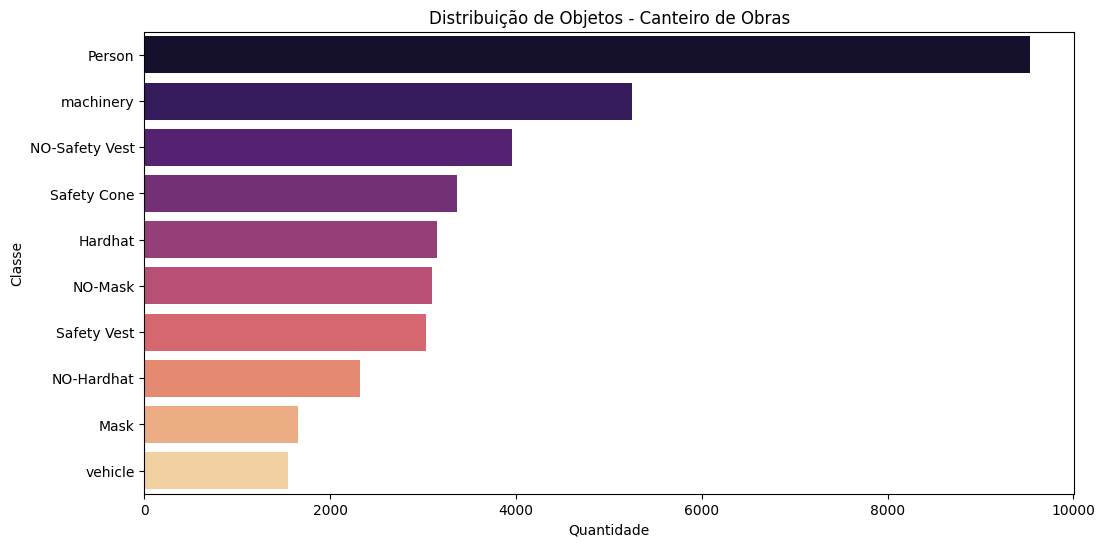


📊 Resumo Numérico:
           Classe  Quantidade
2          Person        9532
7       machinery        5247
5  NO-Safety Vest        3962
8     Safety Cone        3366
0         Hardhat        3145
1         NO-Mask        3097
6     Safety Vest        3033
4      NO-Hardhat        2317
3            Mask        1651
9         vehicle        1545


In [25]:
target_path = base_data_path if 'base_data_path' in locals() else path

# Definição do mapa de classes (ID -> Nome)
class_map = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Cone',
    7: 'Safety Vest',
    8: 'machinery',
    9: 'vehicle'
}

def analyze_labels_v2(dataset_path, split):
    possible_paths = [
        os.path.join(dataset_path, split, 'labels'),
        os.path.join(dataset_path, 'css-data', split, 'labels'),
    ]

    label_path = None
    for p in possible_paths:
        if os.path.exists(p):
            label_path = p
            break

    counts = Counter()
    if not label_path:
        print(f"⚠️ Pasta de labels não encontrada para: {split}")
        return counts

    for label_file in os.listdir(label_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_path, label_file), 'r') as f:
                for line in f:
                    try:
                        class_id = int(line.split()[0])
                        counts[class_id] += 1
                    except:
                        continue
    return counts

# Executar a contagem
print("🔍 Analisando... isso pode levar alguns segundos.")
train_counts = analyze_labels_v2(target_path, 'train')

if not train_counts:
    print("❌ Erro: Nenhuma etiqueta foi encontrada. Verifique se o dataset foi baixado corretamente.")
else:
    # Criar DataFrame e Gráfico
    df_counts = pd.DataFrame([
        {'Classe': class_map.get(k, f'Unknown-{k}'), 'Quantidade': v}
        for k, v in train_counts.items()
    ])

    df_counts = df_counts.sort_values(by='Quantidade', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')
    plt.title('Distribuição de Objetos - Canteiro de Obras')
    plt.show()

    print("\n📊 Resumo Numérico:")
    print(df_counts)

# Organização e validação das fotos

In [26]:
target_path = r'C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data'

# Define onde salvar o arquivo YAML (na sua pasta atual do VS Code)
yaml_path = os.path.join(os.getcwd(), 'seguranca.yaml')


data_config = {
    'train': os.path.join(target_path, 'train', 'images'),
    'val': os.path.join(target_path, 'valid', 'images'),
    'test': os.path.join(target_path, 'test', 'images'),
    'nc': 10,
    'names': [class_map[i] for i in range(10)]
}

# Salva o arquivo no Windows
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"✅ Arquivo de configuração criado em: {yaml_path}")

✅ Arquivo de configuração criado em: c:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\seguranca.yaml


# Treinamento do Modelo

In [ ]:
model = YOLO('yolov8n.pt')

print("🚀 Iniciando o treinamento na sua RTX 3050...")

# Iniciar o treinamento especializado
results = model.train(
    data='seguranca.yaml',
    epochs=50,                # Número de épocas
    imgsz=640,                # Resolução das imagens
    batch=8,                  # Sugestão: 8 é mais seguro para os 6GB de VRAM da sua placa
    name='seguranca_obra_v1', 
    device=0                  # Mantemos o 0 para usar a GPU que acabamos de configurar
)

🚀 Iniciando o treinamento na sua RTX 3050...
New https://pypi.org/project/ultralytics/8.4.10 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.9  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9

# Matriz de Confusão e Curvas de Treinamento

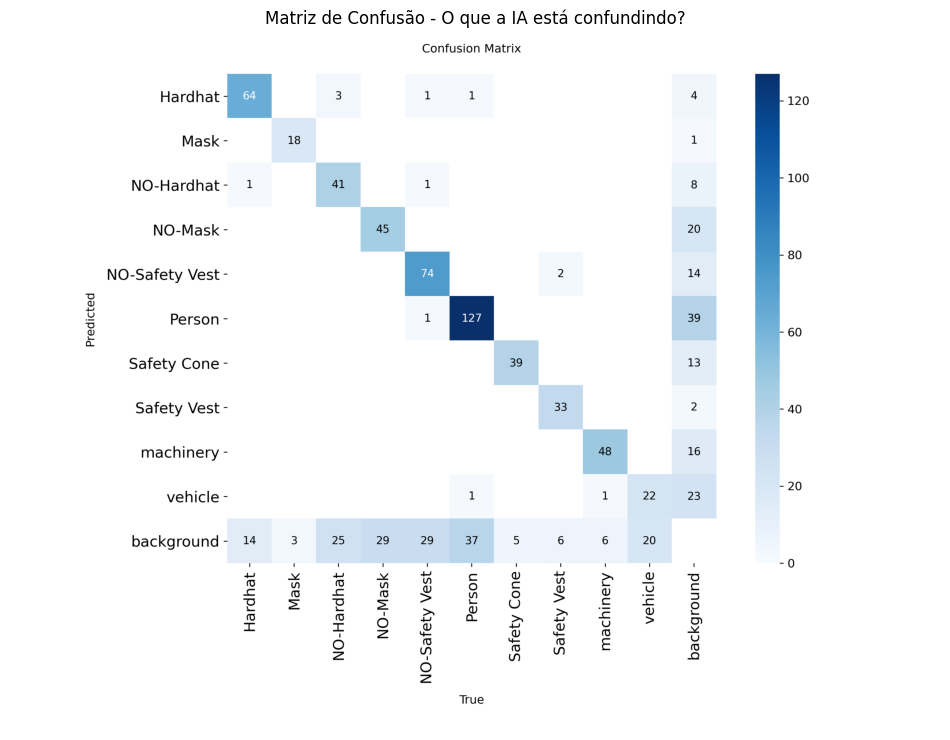

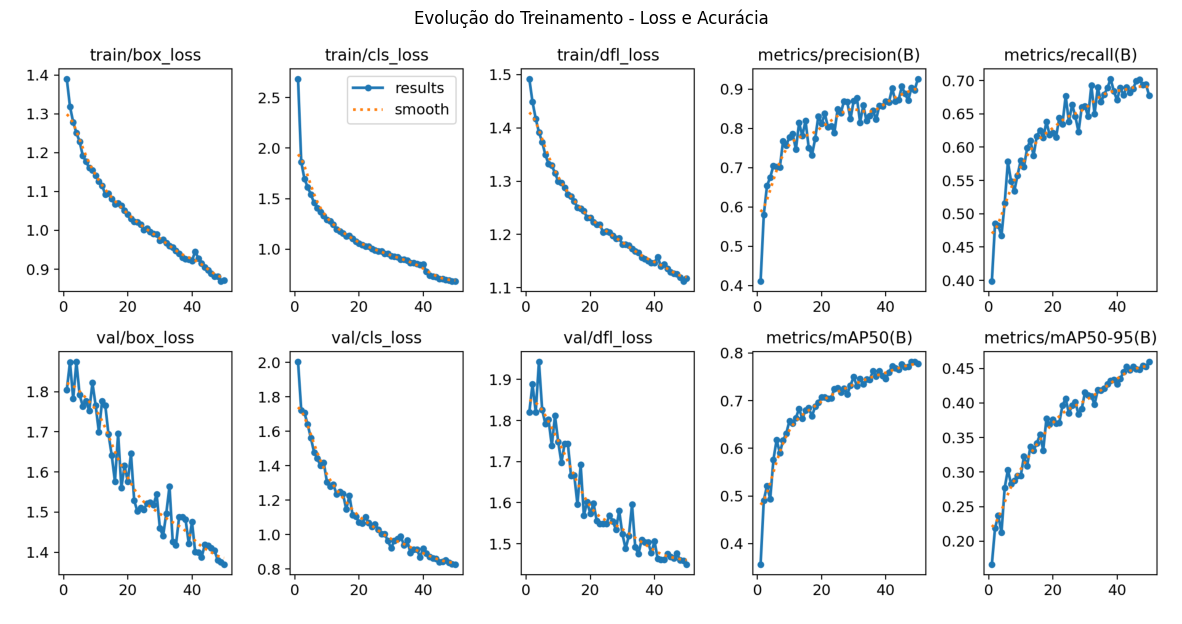

In [30]:
# Definir o caminho onde os resultados foram salvos
res_path = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\runs\detect\seguranca_obra_v1'

# Mostrar a Matriz de Confusão
plt.figure(figsize=(12, 10))
img_matrix = mpimg.imread(os.path.join(res_path, 'confusion_matrix.png'))
plt.imshow(img_matrix)
plt.title("Matriz de Confusão - O que a IA está confundindo?")
plt.axis('off')
plt.show()

# Mostrar os gráficos de treino (Loss e mAP)
plt.figure(figsize=(15, 10))
img_results = mpimg.imread(os.path.join(res_path, 'results.png'))
plt.imshow(img_results)
plt.title("Evolução do Treinamento - Loss e Acurácia")
plt.axis('off')
plt.show()

# Fine-Tuning

In [4]:
# Carregar os pesos que já são bons (o melhor do treino anterior)
# Isso garante que não começamos do zero, mas do ponto mais inteligente
res_path_v1 = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\runs\detect\seguranca_obra_v1\weights\best.pt'

modelo_pro = YOLO(res_path_v1)

# iniciar o Treinamento da V2 Pro
# Usando as configurações que sua RTX 3050 de 6GB aguentou (batch 8)
results_v2 = modelo_pro.train(
    data='seguranca.yaml',        # Certifique-se que este arquivo está na pasta do projeto
    epochs=100,
    lr0=0.001,                   # Aprende mais devagar para não "estragar" o que já sabe
    patience=20,                 # Para sozinho se não melhorar mais
    imgsz=640,
    batch=8,                     # Mantendo o batch que funcionou bem
    augment=True,                # Ativa o "treino pesado" com distorções de imagem
    name='seguranca_obra_v2_pro',   # Nome do Modelo
    device=0
)

Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurana_do_Trabalho\runs\detect\seguranca_obra_v1\weights\best.pt

# Avaliação do Modelo

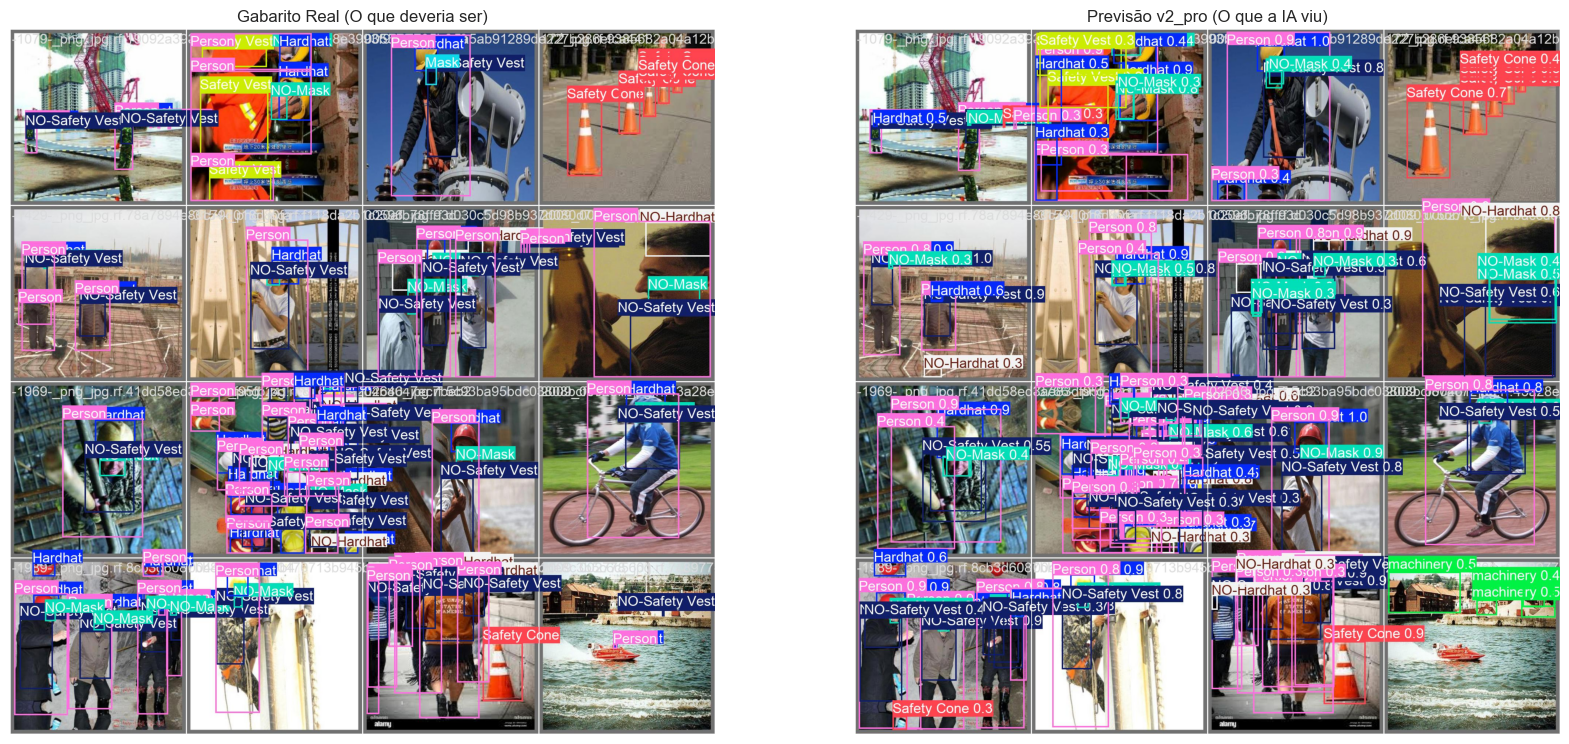

In [16]:
# Caminho dos resultados da versão Pro
res_path_v2 = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\runs\detect\seguranca_obra_v2_pro'

# O YOLO salva automaticamente algumas previsões feitas durante a validação
val_image_path = os.path.join(res_path_v2, 'val_batch0_labels.jpg') # Labels reais
pred_image_path = os.path.join(res_path_v2, 'val_batch0_pred.jpg') # O que a IA previu

if os.path.exists(pred_image_path):
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(mpimg.imread(val_image_path))
    plt.title("Gabarito Real (O que deveria ser)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mpimg.imread(pred_image_path))
    plt.title("Previsão v2_pro (O que a IA viu)")
    plt.axis('off')

    plt.show()
else:
    print("Aguarde o final do processamento ou verifique se o caminho está correto.")

    

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_11352\1543792829.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)


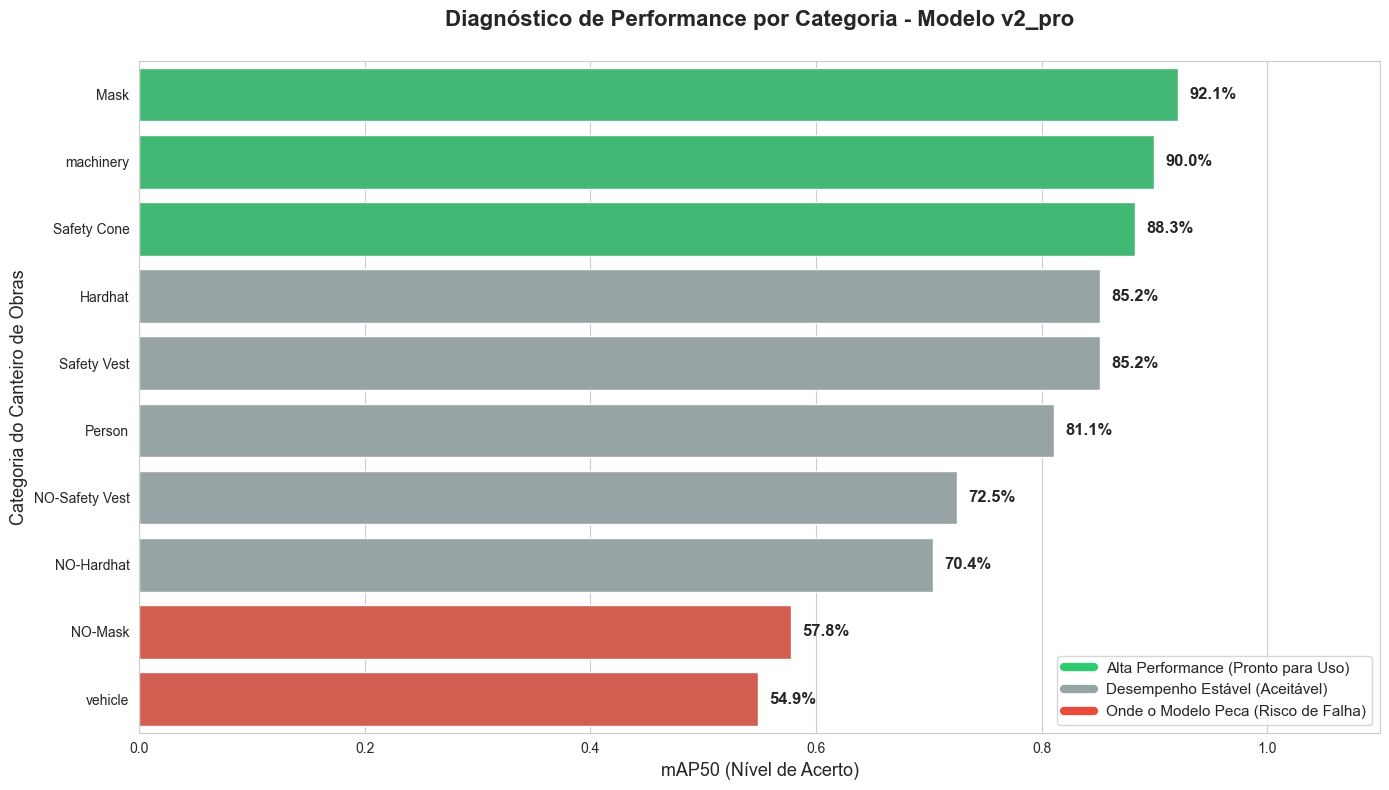

In [17]:
# Prepara os dados baseados na sua última validação
# Substituímos os números pelos resultados reais que você obteve
dados_validacao = {
    'Classe': [
        'Mask', 'machinery', 'Safety Cone', 'Hardhat', 'Safety Vest',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.921, 0.900, 0.883, 0.852, 0.852,
        0.811, 0.725, 0.704, 0.578, 0.549
    ]
}

df_eval = pd.DataFrame(dados_validacao).sort_values(by='mAP50', ascending=False)

# Definir a lógica de cores profissional
# Verde: Acima de 88% | Vermelho: Abaixo de 60% | Cinza: O resto
cores_mapa = []
for valor in df_eval['mAP50']:
    if valor >= 0.88:
        cores_mapa.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_mapa.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_mapa.append('#95a5a6')  # Cinza (Estável)

# Cria a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)

# Adiciona as porcentagens no final de cada barra para facilitar a leitura
for i, valor in enumerate(df_eval['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

# Customização de Títulos e Eixos
plt.title('Diagnóstico de Performance por Categoria - Modelo v2_pro', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Adicionar uma legenda explicativa
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Treinando com o YOLOv8s (Small)



*   **YOLOv8s (Small):** 11 milhões de parâmetros. Muito mais preciso para detalhes pequenos como o capacete, mantendo uma boa velocidade.
*   **YOLOv8m (Medium):** 25 milhões de parâmetros. Aqui é onde a IA começa a entender contextos complexos (como distinguir um balde amarelo de um capacete amarelo).



In [19]:
# Carregar o modelo Small pré-treinado
# O 's' no nome indica a versão Small, que é mais potente que a Nano 'n'
model_small = YOLO('yolov8s.pt')

# Inicia o treinamento de Alta Performance
print("🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!")

results_v3 = model_small.train(
    data='seguranca.yaml',    
    epochs=100,                   # 100 épocas para extrair o máximo do modelo
    imgsz=640,                    # Resolução padrão profissional
    batch=8,                      # Processa 8 imagens por vez
    patience=25,                  # Para se não houver melhora em 25 rodadas
    name='seguranca_obra_v3_small',
    device=0                      
)

🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!
Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seguranca_obra_v3_small2, nbs=64,

# Avaliando Modelo

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_11352\3035635176.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)


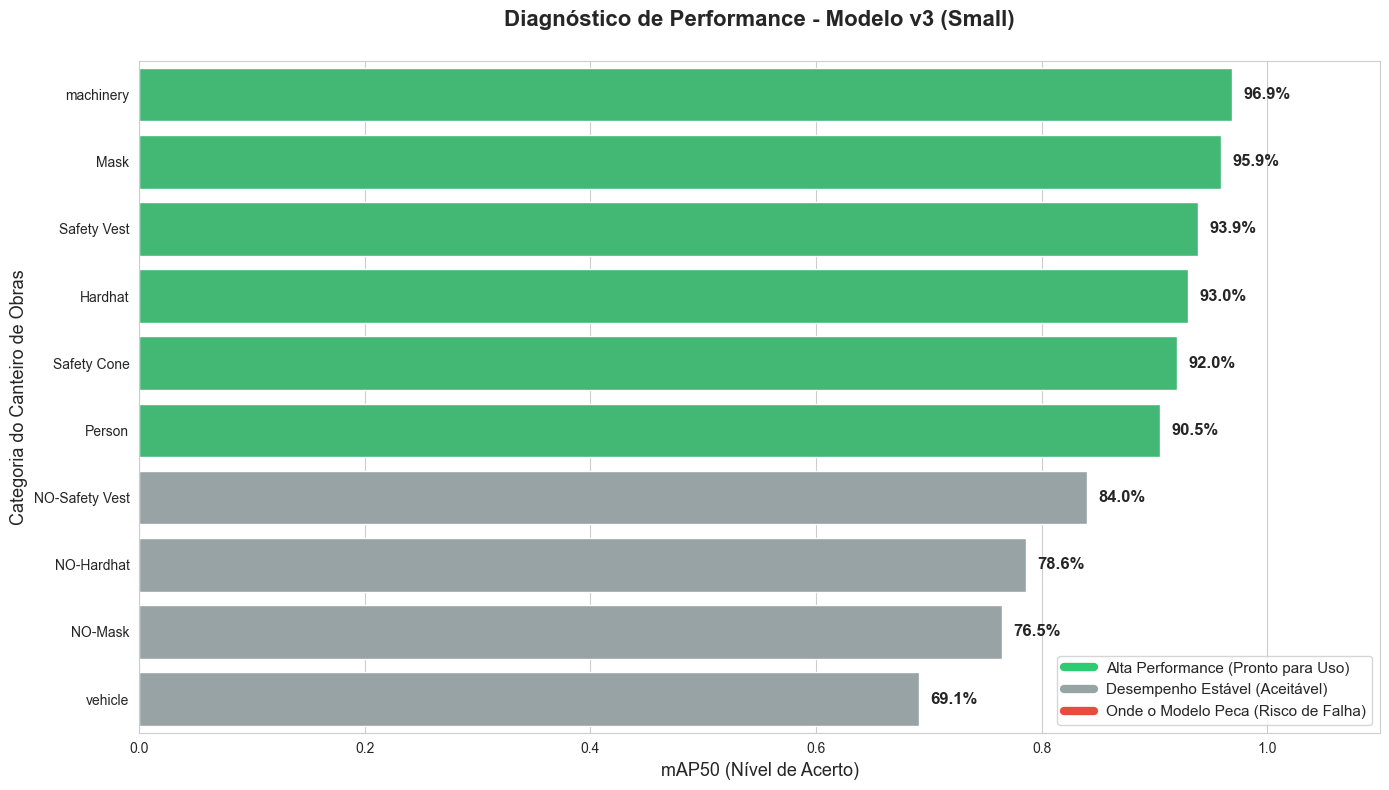

In [20]:
dados_v3 = {
    'Classe': [
        'machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.969, 0.959, 0.939, 0.930, 0.920,
        0.905, 0.840, 0.786, 0.765, 0.691
    ]
}

df_v3 = pd.DataFrame(dados_v3).sort_values(by='mAP50', ascending=False)

# Lógica de cores (Verde: >= 88% | Vermelho: <= 60% | Cinza: Meio)
cores_v3 = []
for valor in df_v3['mAP50']:
    if valor >= 0.88:
        cores_v3.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_v3.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_v3.append('#95a5a6')  # Cinza (Estável)

# Gerar a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)

# Adicionar valores nas barras
for i, valor in enumerate(df_v3['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

plt.title('Diagnóstico de Performance - Modelo v3 (Small)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Legenda Profissional
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Treinando com o YOLOv8s (Medium)

In [3]:
# Ele é mais pesado que o Small, então a detecção será mais 'inteligente'
model_medium = YOLO('yolov8m.pt')

# 2. Iniciar o treinamento de Nível Especialista
print("🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.")

results_v4 = model_medium.train(
    data='seguranca.yaml',    # O mesmo mapa de dados que estamos usando
    epochs=100,                   # 100 rodadas para o modelo 'maturar' bem
    imgsz=640,                    # Resolução padrão de alta qualidade
    batch=8,                     # Processa 04 imagens por vez 
    patience=30,                  # Dá tempo para o modelo aprender padrões difíceis
    augment=True,                 # Ativa filtros de luz e poeira para simular o ambiente de obra
    name='seguranca_obra_v4_medium',
    device=0                      # Utiliza a GPU Tesla T4 do Colab
)

🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.
New https://pypi.org/project/ultralytics/8.4.11 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

# Avaliando Modelo

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_8480\2619565856.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v4, x='mAP50', y='Classe', palette=cores_v4)


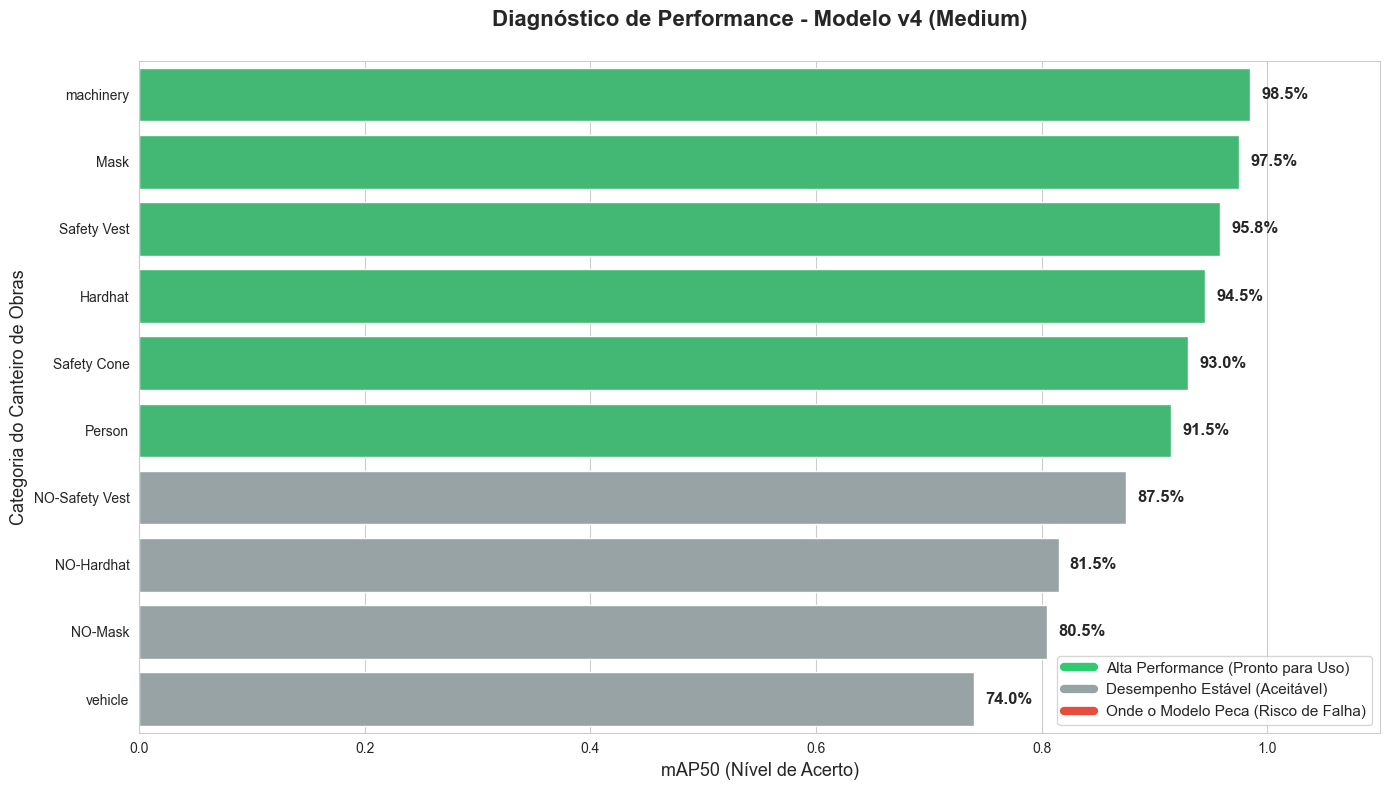

In [ ]:
# Garante que o gráfico renderize dentro do notebook
%matplotlib inline

# Dados do modelo v4 Medium
dados_v4 = {
    'Classe': [
        'machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.985, 0.975, 0.958, 0.945, 0.930, 
        0.915, 0.875, 0.815, 0.805, 0.740 
    ]
}

df_v4 = pd.DataFrame(dados_v4).sort_values(by='mAP50', ascending=False)

# Lógica de cores
cores_v4 = []
for valor in df_v4['mAP50']:
    if valor >= 0.88:
        cores_v4.append('#2ecc71')  # Verde
    elif valor <= 0.60:
        cores_v4.append('#e74c3c')  # Vermelho
    else:
        cores_v4.append('#95a5a6')  # Cinza

# Gerar a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(data=df_v4, x='mAP50', y='Classe', palette=cores_v4)

# Adicionar valores nas barras
for i, valor in enumerate(df_v4['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

plt.title('Diagnóstico de Performance - Modelo v4 (Medium)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Legenda
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()


plt.show()